In [ ]:
import pandas as pd

# Replace this with the CSV export URL you obtained from 'Publish to web'
google_sheet_csv_url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vTHqIPg1CdKm3_Oez-nIhqNSkt15jtsK0UnkAlNlhC79GdBK5IGqwxmx1faRcD2wBo2pvs1I1Hjvc7F/pub?gid=0&single=true&output=csv'

try:
    df = pd.read_csv(google_sheet_csv_url)
    print("Google Sheet data loaded successfully into a pandas DataFrame!")
except Exception as e:
    print(f"Error loading Google Sheet: {e}")
    print("Please ensure the sheet is published to the web as a CSV and the URL is correct.")

Google Sheet data loaded successfully into a pandas DataFrame!


In [ ]:
df

,text,true_label,BOTH 80.6,BERT 80.2,Target Type,Intent Clarity,Context Dependence
0,Während AfD-MdB Martin Reichardt seine Partei ...,0,0,0,Non-protected group,No harmful intent,Requires cultural or political knowledge
1,"Wer hier Naziverhalten sieht, hat ein Rederech...",1,1,1,Protected group,Explicit and literal,Requires cultural or political knowledge
2,@heinrichwiechm1 @MiriamOzen Aufstand der deut...,0,0,0,Non-protected group,Implicit or coded,Self-contained
3,"@Moebbeck @bodoramelow Sie wird entlarvt, weil...",0,1,1,Individual person,Implicit or coded,Requires conversational context
4,"@ARD_BaB @HeikoMaas Was hat eine abgewählte, d...",1,1,1,Individual person,Explicit and literal,Requires cultural or political knowledge
...,...,...,...,...,...,...,...
997,"@ufhoven Gutmenschen lieben es, mit Zitaten au...",1,0,1,Protected group,Implicit or coded,Requires cultural or political knowledge
998,@BROT_furdiewelt Ihr entscheidet auch nicht da...,0,0,0,Non-protected group,No harmful intent,Requires conversational context
999,Allein das Wahlsystem im Schland ist Betrug am...,0,0,0,Non-protected group,Implicit or coded,Self-contained
1000,@emrich_5933 @DuHugonotte @CDU Wo war das Merk...,0,0,0,Individual person,Implicit or coded,Requires cultural or political knowledge


In [ ]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Convert specified columns to 'category' data type
df['Target Type'] = df['Target Type'].astype('category')
df['Intent Clarity'] = df['Intent Clarity'].astype('category')
df['Context Dependence'] = df['Context Dependence'].astype('category')

print("Libraries imported successfully.")
print("Columns 'Target Type', 'Intent Clarity', and 'Context Dependence' converted to category type.")

Libraries imported successfully.
Columns 'Target Type', 'Intent Clarity', and 'Context Dependence' converted to category type.


ANOVA for Target Type:
                         sum_sq     df           F        PR(>F)
C(Q("Target Type"))   54.885267    3.0  107.975352  1.518967e-60
Residual             169.098765  998.0         NaN           NaN


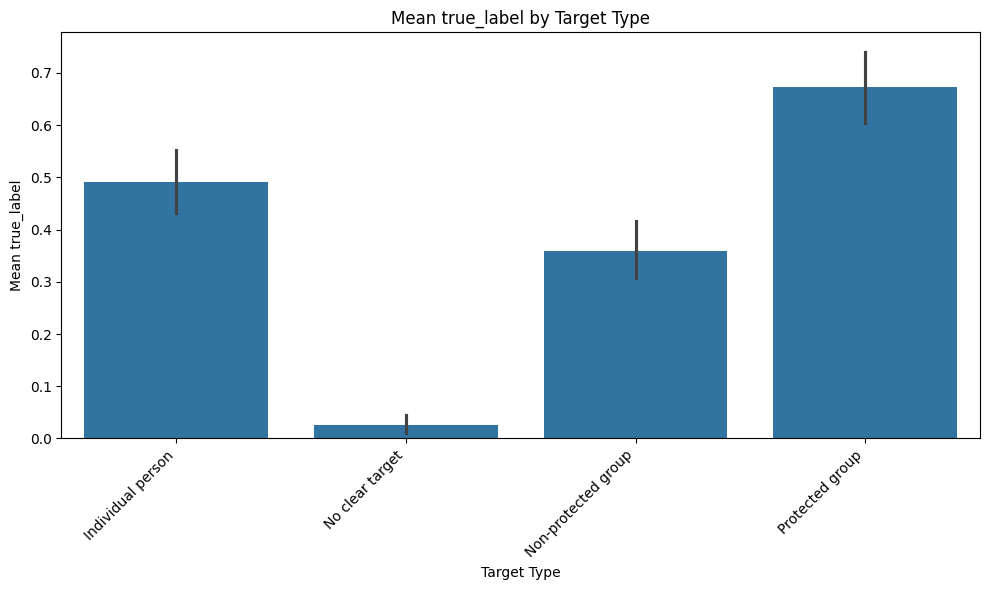

In [ ]:
import statsmodels.api as sm

# Perform one-way ANOVA for 'Target Type'
model_target_type = smf.ols('true_label ~ C(Q("Target Type"))', data=df).fit()
anova_table_target_type = sm.stats.anova_lm(model_target_type, typ=2)
print("ANOVA for Target Type:")
print(anova_table_target_type)

# Create bar plot for 'Target Type'
plt.figure(figsize=(10, 6))
sns.barplot(x='Target Type', y='true_label', data=df, errorbar='ci')
plt.xlabel('Target Type')
plt.ylabel('Mean true_label')
plt.title('Mean true_label by Target Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ANOVA for Intent Clarity:
                            sum_sq     df           F         PR(>F)
C(Q("Intent Clarity"))   88.761984    3.0  218.367892  6.853159e-109
Residual                135.222047  998.0         NaN            NaN


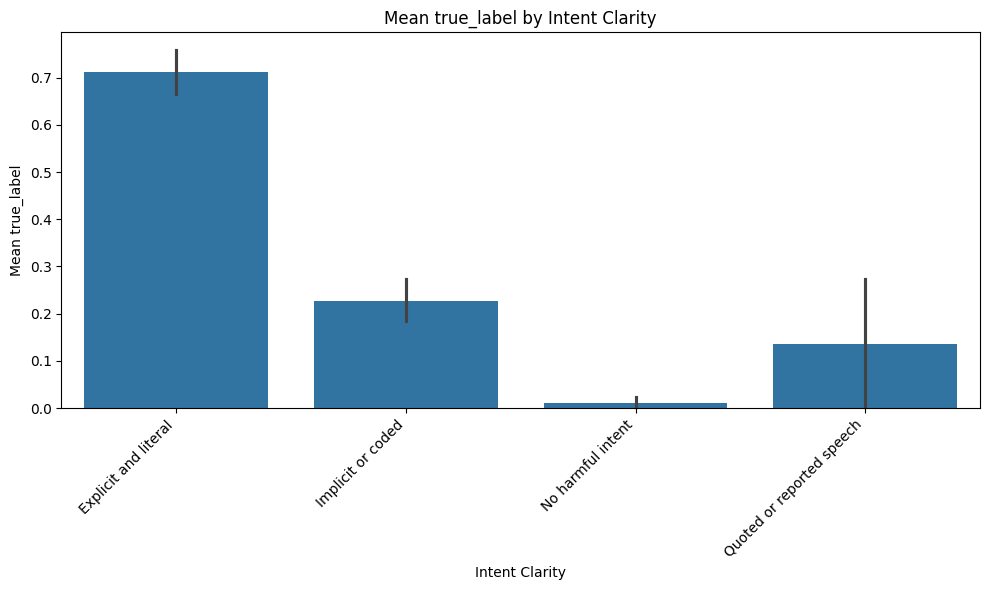

In [ ]:
import statsmodels.api as sm

# Perform one-way ANOVA for 'Intent Clarity'
model_intent_clarity = smf.ols('true_label ~ C(Q("Intent Clarity"))', data=df).fit()
anova_table_intent_clarity = sm.stats.anova_lm(model_intent_clarity, typ=2)
print("ANOVA for Intent Clarity:")
print(anova_table_intent_clarity)

# Create bar plot for 'Intent Clarity'
plt.figure(figsize=(10, 6))
sns.barplot(x='Intent Clarity', y='true_label', data=df, errorbar='ci')
plt.xlabel('Intent Clarity')
plt.ylabel('Mean true_label')
plt.title('Mean true_label by Intent Clarity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ANOVA for Context Dependence:
                                sum_sq     df         F    PR(>F)
C(Q("Context Dependence"))    3.213797    2.0  7.271323  0.000733
Residual                    220.770235  999.0       NaN       NaN


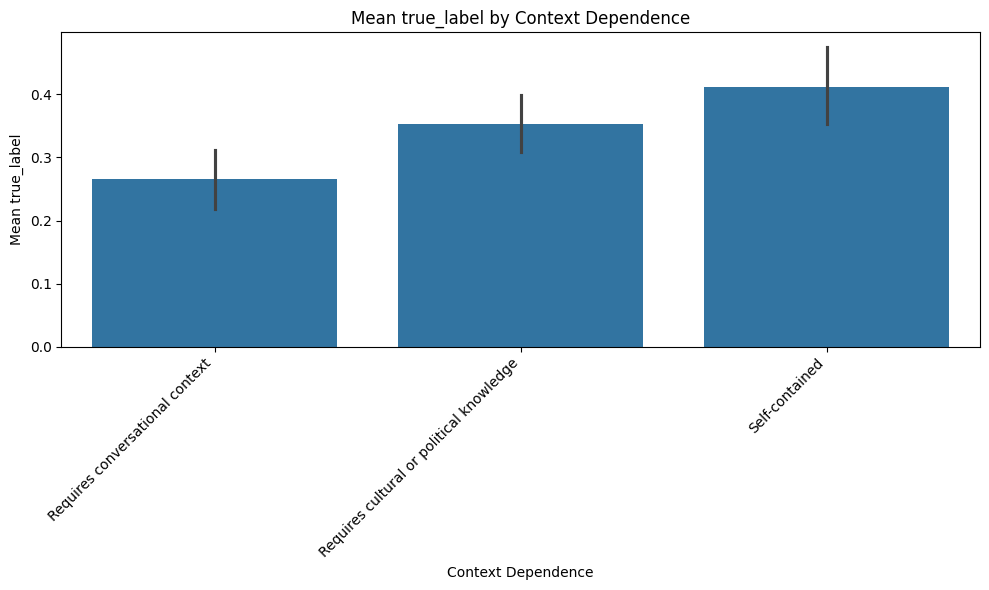

In [ ]:
import statsmodels.api as sm

# Perform one-way ANOVA for 'Context Dependence'
model_context_dependence = smf.ols('true_label ~ C(Q("Context Dependence"))', data=df).fit()
anova_table_context_dependence = sm.stats.anova_lm(model_context_dependence, typ=2)
print("ANOVA for Context Dependence:")
print(anova_table_context_dependence)

# Create bar plot for 'Context Dependence'
plt.figure(figsize=(10, 6))
sns.barplot(x='Context Dependence', y='true_label', data=df, errorbar='ci')
plt.xlabel('Context Dependence')
plt.ylabel('Mean true_label')
plt.title('Mean true_label by Context Dependence')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Two-Way ANOVA for Target Type and Intent Clarity (with interaction):
                                                sum_sq     df           F  \
C(Q("Target Type"))                           9.281816    3.0   24.645237   
C(Q("Intent Clarity"))                       43.158534    3.0  114.595281   
C(Q("Target Type")):C(Q("Intent Clarity"))    2.158769    9.0    1.910667   
Residual                                    123.781462  986.0         NaN   

                                                  PR(>F)  
C(Q("Target Type"))                         2.214405e-15  
C(Q("Intent Clarity"))                      1.157859e-63  
C(Q("Target Type")):C(Q("Intent Clarity"))  4.704913e-02  
Residual                                             NaN  


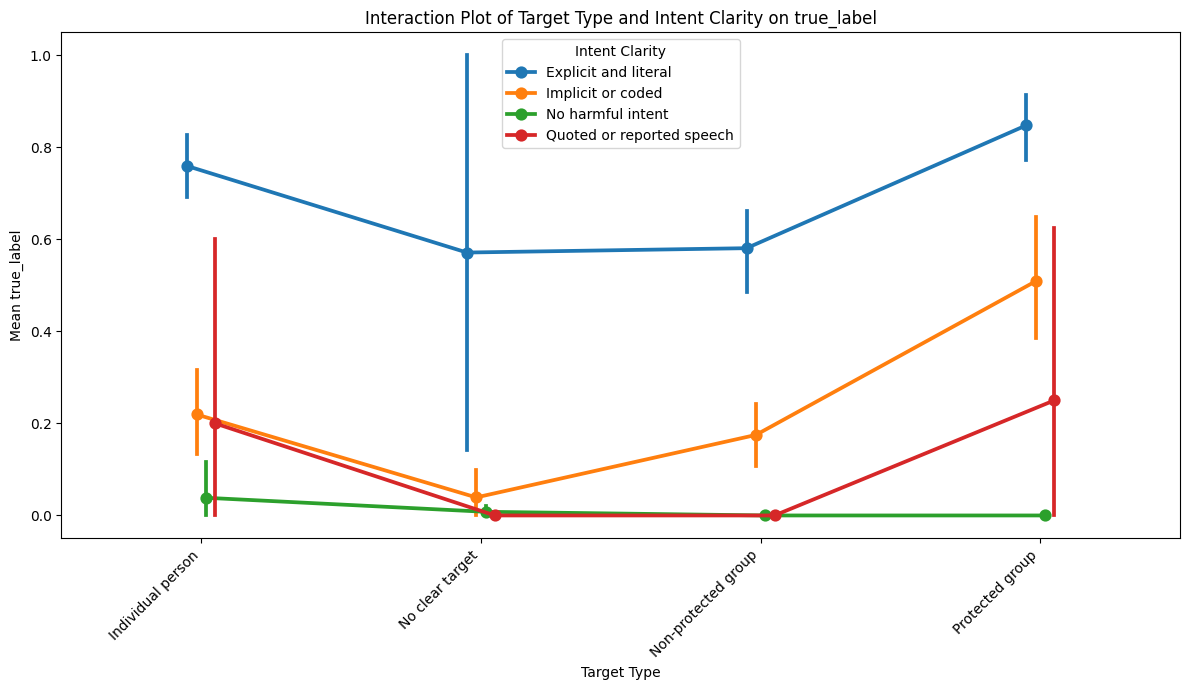

In [ ]:
import statsmodels.api as sm

# Perform two-way ANOVA for 'Target Type' and 'Intent Clarity' with interaction
model_interaction = smf.ols('true_label ~ C(Q("Target Type")) * C(Q("Intent Clarity"))', data=df).fit()
anova_table_interaction = sm.stats.anova_lm(model_interaction, typ=2)
print("Two-Way ANOVA for Target Type and Intent Clarity (with interaction):")
print(anova_table_interaction)

# Create interaction plot
plt.figure(figsize=(12, 7))
sns.pointplot(x='Target Type', y='true_label', hue='Intent Clarity', data=df, errorbar='ci', dodge=True)
plt.xlabel('Target Type')
plt.ylabel('Mean true_label')
plt.title('Interaction Plot of Target Type and Intent Clarity on true_label')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Intent Clarity')
plt.tight_layout()
plt.show()

Two-Way ANOVA for Target Type and Context Dependence (with interaction):
                                                    sum_sq     df           F  \
C(Q("Target Type"))                              54.053399    3.0  108.099694   
C(Q("Context Dependence"))                        2.381929    2.0    7.145317   
C(Q("Target Type")):C(Q("Context Dependence"))    1.705994    6.0    1.705882   
Residual                                        165.010842  990.0         NaN   

                                                      PR(>F)  
C(Q("Target Type"))                             1.525220e-60  
C(Q("Context Dependence"))                      8.298739e-04  
C(Q("Target Type")):C(Q("Context Dependence"))  1.163481e-01  
Residual                                                 NaN  


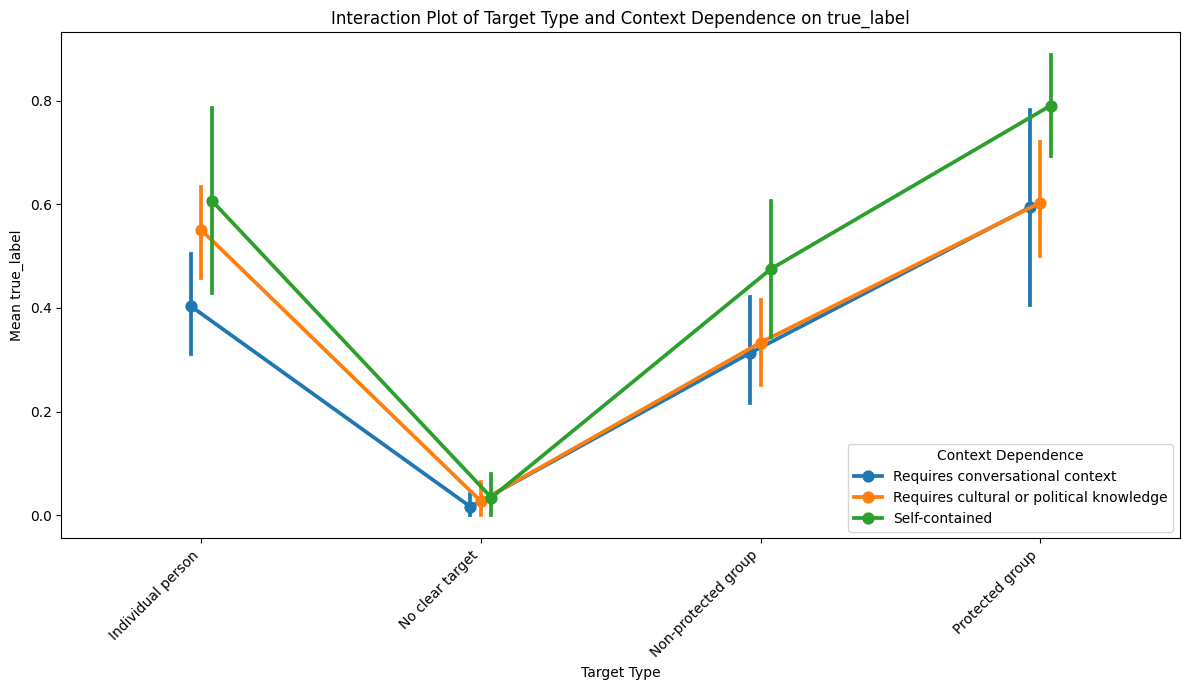

In [ ]:
import statsmodels.api as sm

# Perform two-way ANOVA for 'Target Type' and 'Context Dependence' with interaction
model_interaction_2 = smf.ols('true_label ~ C(Q("Target Type")) * C(Q("Context Dependence"))', data=df).fit()
anova_table_interaction_2 = sm.stats.anova_lm(model_interaction_2, typ=2)
print("Two-Way ANOVA for Target Type and Context Dependence (with interaction):")
print(anova_table_interaction_2)

# Create interaction plot
plt.figure(figsize=(12, 7))
sns.pointplot(x='Target Type', y='true_label', hue='Context Dependence', data=df, errorbar='ci', dodge=True)
plt.xlabel('Target Type')
plt.ylabel('Mean true_label')
plt.title('Interaction Plot of Target Type and Context Dependence on true_label')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Context Dependence')
plt.tight_layout()
plt.show()

Two-Way ANOVA for Intent Clarity and Context Dependence (with interaction):
                                                       sum_sq     df  \
C(Q("Intent Clarity"))                              85.709386    3.0   
C(Q("Context Dependence"))                           0.161199    2.0   
C(Q("Intent Clarity")):C(Q("Context Dependence"))    0.323864    6.0   
Residual                                           134.736985  990.0   

                                                            F         PR(>F)  
C(Q("Intent Clarity"))                             209.920813  2.273274e-105  
C(Q("Context Dependence"))                           0.592216   5.532962e-01  
C(Q("Intent Clarity")):C(Q("Context Dependence"))    0.396606   8.814785e-01  
Residual                                                  NaN            NaN  


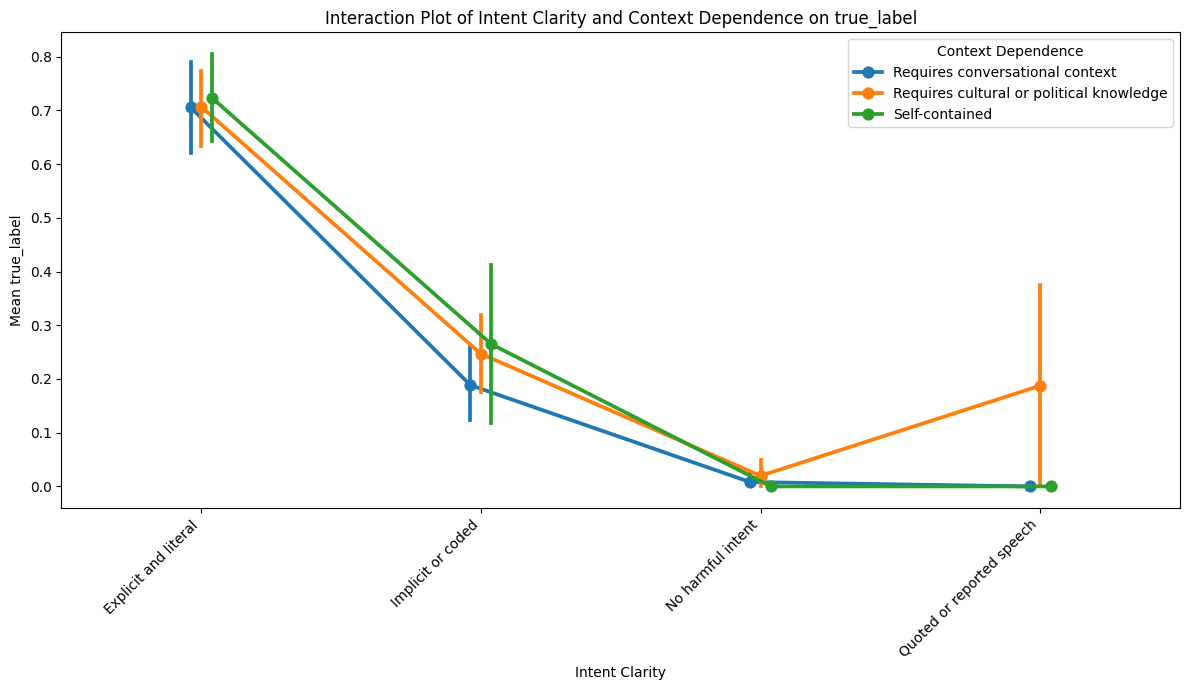

In [ ]:
import statsmodels.api as sm

# Perform two-way ANOVA for 'Intent Clarity' and 'Context Dependence' with interaction
model_interaction_3 = smf.ols('true_label ~ C(Q("Intent Clarity")) * C(Q("Context Dependence"))', data=df).fit()
anova_table_interaction_3 = sm.stats.anova_lm(model_interaction_3, typ=2)
print("Two-Way ANOVA for Intent Clarity and Context Dependence (with interaction):")
print(anova_table_interaction_3)

# Create interaction plot
plt.figure(figsize=(12, 7))
sns.pointplot(x='Intent Clarity', y='true_label', hue='Context Dependence', data=df, errorbar='ci', dodge=True)
plt.xlabel('Intent Clarity')
plt.ylabel('Mean true_label')
plt.title('Interaction Plot of Intent Clarity and Context Dependence on true_label')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Context Dependence')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Define the desired order for 'Target Type' categories
target_type_order = ['No clear target', 'Non-protected group', 'Individual person', 'Protected group']

# Create a CategoricalDtype with the specified order
ordered_target_type = pd.CategoricalDtype(categories=target_type_order, ordered=True)

# Apply the new categorical order to the 'Target Type' column
df['Target Type'] = df['Target Type'].astype(ordered_target_type)

print("Categories for 'Target Type' reordered successfully.")
print(df['Target Type'].dtype)

Categories for 'Target Type' reordered successfully.
category


In [ ]:
import pandas as pd

# Define the desired order for 'Intent Clarity' categories
intent_clarity_order = ['No harmful intent', 'Quoted or reported speech', 'Implicit or coded', 'Explicit and literal']

# Create a CategoricalDtype with the specified order
ordered_intent_clarity = pd.CategoricalDtype(categories=intent_clarity_order, ordered=True)

# Apply the new categorical order to the 'Intent Clarity' column
df['Intent Clarity'] = df['Intent Clarity'].astype(ordered_intent_clarity)

print("Categories for 'Intent Clarity' reordered successfully.")
print(df['Intent Clarity'].dtype)

Categories for 'Intent Clarity' reordered successfully.
category


Two-Way ANOVA for Reordered Target Type and Intent Clarity (with interaction):
                                                sum_sq     df           F  \
C(Q("Target Type"))                           9.281816    3.0   24.645237   
C(Q("Intent Clarity"))                       43.158534    3.0  114.595281   
C(Q("Target Type")):C(Q("Intent Clarity"))    2.158769    9.0    1.910667   
Residual                                    123.781462  986.0         NaN   

                                                  PR(>F)  
C(Q("Target Type"))                         2.214405e-15  
C(Q("Intent Clarity"))                      1.157859e-63  
C(Q("Target Type")):C(Q("Intent Clarity"))  4.704913e-02  
Residual                                             NaN  


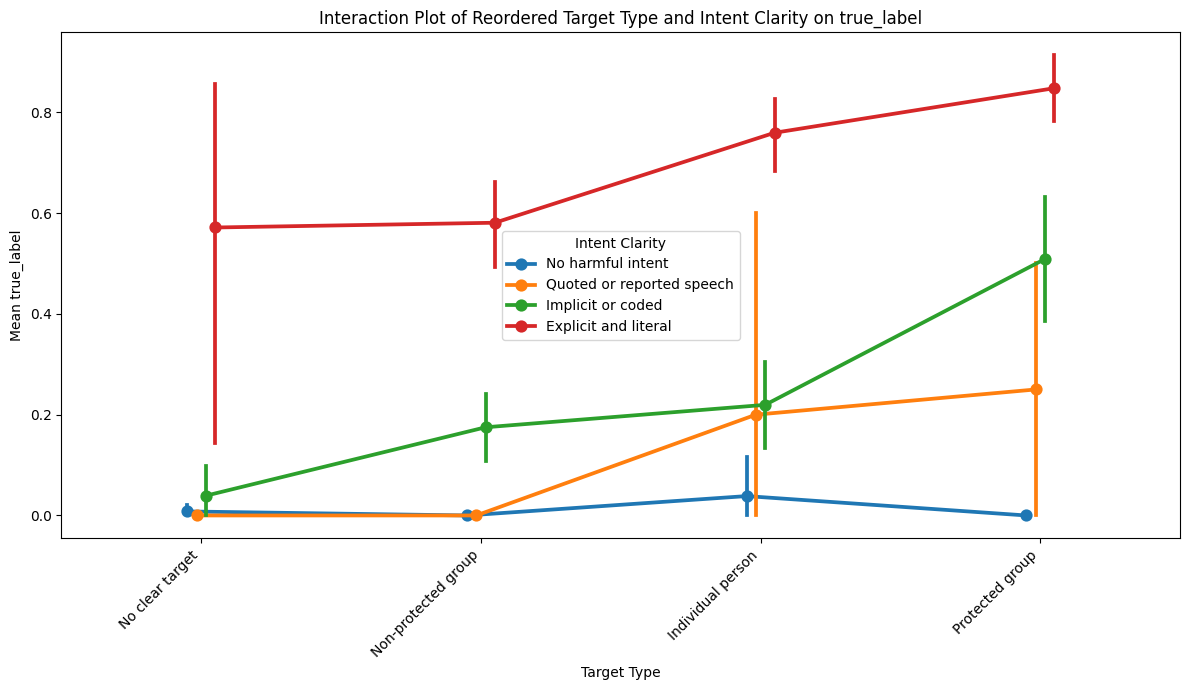

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Perform two-way ANOVA for reordered 'Target Type' and 'Intent Clarity' with interaction
model_interaction_reordered = smf.ols('true_label ~ C(Q("Target Type")) * C(Q("Intent Clarity"))', data=df).fit()
anova_table_interaction_reordered = sm.stats.anova_lm(model_interaction_reordered, typ=2)
print("Two-Way ANOVA for Reordered Target Type and Intent Clarity (with interaction):")
print(anova_table_interaction_reordered)

# Create interaction plot
plt.figure(figsize=(12, 7))
sns.pointplot(x='Target Type', y='true_label', hue='Intent Clarity', data=df, errorbar='ci', dodge=True)
plt.xlabel('Target Type')
plt.ylabel('Mean true_label')
plt.title('Interaction Plot of Reordered Target Type and Intent Clarity on true_label')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Intent Clarity')
plt.tight_layout()
plt.show()

Two-Way ANOVA for Reordered Target Type and Context Dependence (with interaction):
                                                    sum_sq     df           F  \
C(Q("Target Type"))                              54.053399    3.0  108.099694   
C(Q("Context Dependence"))                        2.381929    2.0    7.145317   
C(Q("Target Type")):C(Q("Context Dependence"))    1.705994    6.0    1.705882   
Residual                                        165.010842  990.0         NaN   

                                                      PR(>F)  
C(Q("Target Type"))                             1.525220e-60  
C(Q("Context Dependence"))                      8.298739e-04  
C(Q("Target Type")):C(Q("Context Dependence"))  1.163481e-01  
Residual                                                 NaN  


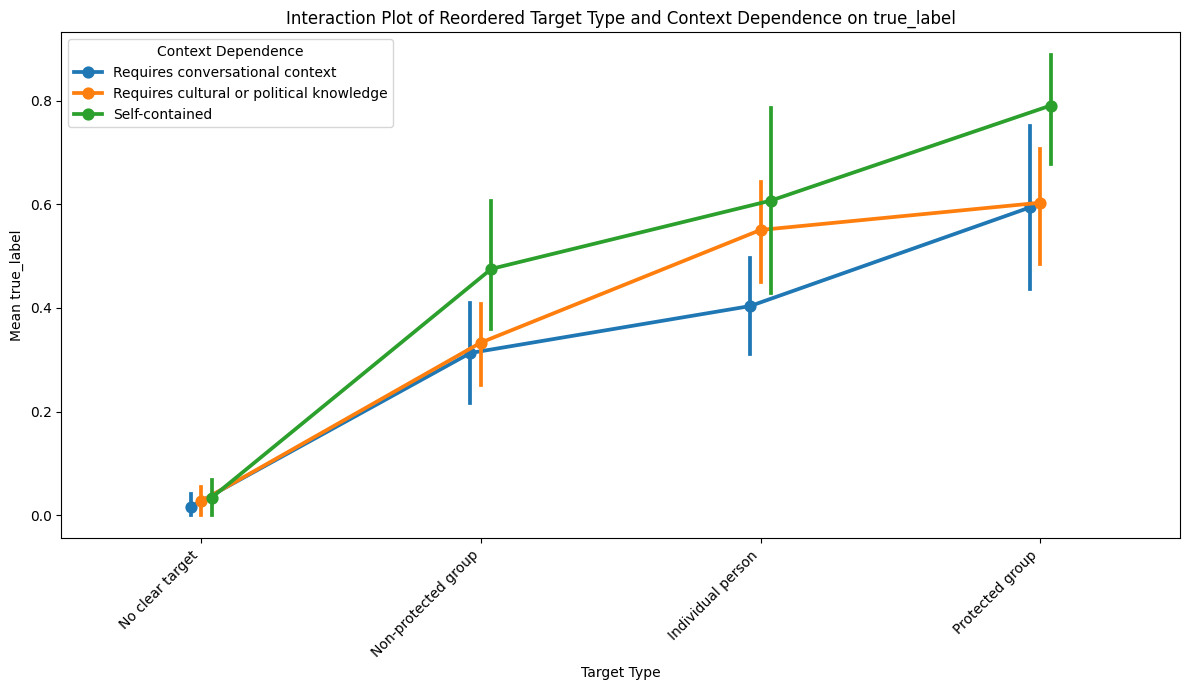

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Perform two-way ANOVA for reordered 'Target Type' and 'Context Dependence' with interaction
model_interaction_reordered_2 = smf.ols('true_label ~ C(Q("Target Type")) * C(Q("Context Dependence"))', data=df).fit()
anova_table_interaction_reordered_2 = sm.stats.anova_lm(model_interaction_reordered_2, typ=2)
print("Two-Way ANOVA for Reordered Target Type and Context Dependence (with interaction):")
print(anova_table_interaction_reordered_2)

# Create interaction plot
plt.figure(figsize=(12, 7))
sns.pointplot(x='Target Type', y='true_label', hue='Context Dependence', data=df, errorbar='ci', dodge=True)
plt.xlabel('Target Type')
plt.ylabel('Mean true_label')
plt.title('Interaction Plot of Reordered Target Type and Context Dependence on true_label')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Context Dependence')
plt.tight_layout()
plt.show()

Two-Way ANOVA for Reordered Intent Clarity and Context Dependence (with interaction):
                                                       sum_sq     df  \
C(Q("Intent Clarity"))                              85.709386    3.0   
C(Q("Context Dependence"))                           0.161199    2.0   
C(Q("Intent Clarity")):C(Q("Context Dependence"))    0.323864    6.0   
Residual                                           134.736985  990.0   

                                                            F         PR(>F)  
C(Q("Intent Clarity"))                             209.920813  2.273274e-105  
C(Q("Context Dependence"))                           0.592216   5.532962e-01  
C(Q("Intent Clarity")):C(Q("Context Dependence"))    0.396606   8.814785e-01  
Residual                                                  NaN            NaN  


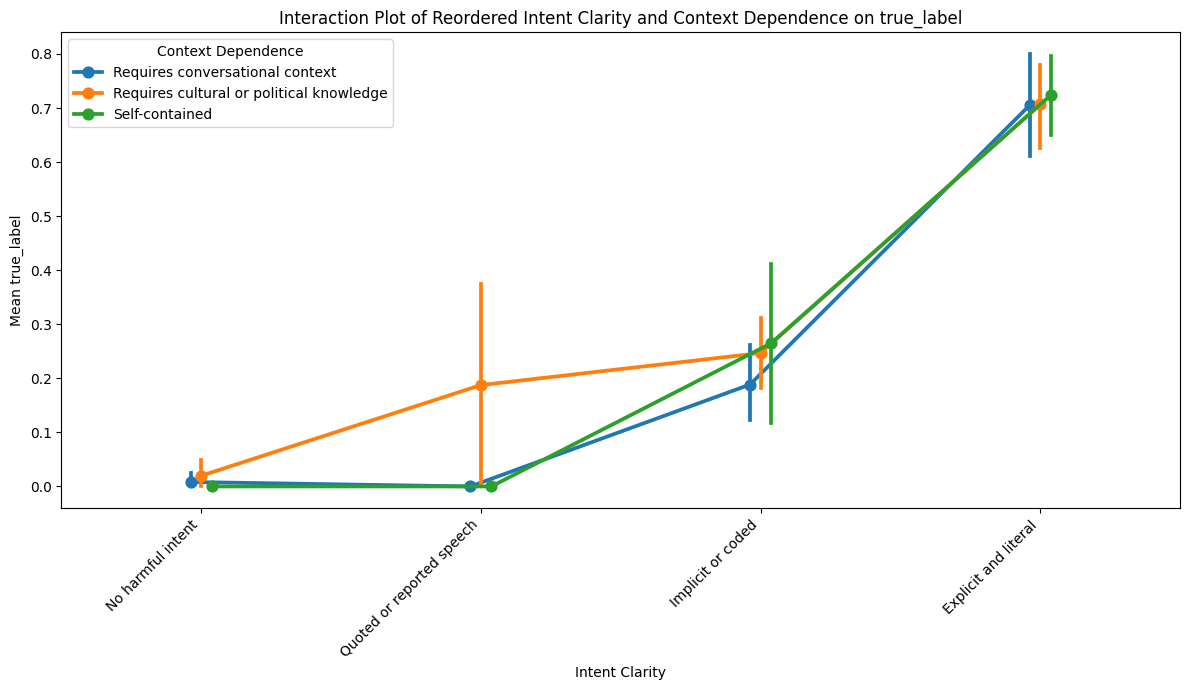

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Perform two-way ANOVA for 'Intent Clarity' and 'Context Dependence' with interaction
model_interaction_reordered_3 = smf.ols('true_label ~ C(Q("Intent Clarity")) * C(Q("Context Dependence"))', data=df).fit()
anova_table_interaction_reordered_3 = sm.stats.anova_lm(model_interaction_reordered_3, typ=2)
print("Two-Way ANOVA for Reordered Intent Clarity and Context Dependence (with interaction):")
print(anova_table_interaction_reordered_3)

# Create interaction plot
plt.figure(figsize=(12, 7))
sns.pointplot(x='Intent Clarity', y='true_label', hue='Context Dependence', data=df, errorbar='ci', dodge=True)
plt.xlabel('Intent Clarity')
plt.ylabel('Mean true_label')
plt.title('Interaction Plot of Reordered Intent Clarity and Context Dependence on true_label')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Context Dependence')
plt.tight_layout()
plt.show()

In [ ]:
df['both_correct'] = (df['BOTH 80.6'] == df['true_label']).astype(int)
df['bert_correct'] = (df['BERT 80.2'] == df['true_label']).astype(int)

print("New columns 'both_correct' and 'bert_correct' created successfully.")
df.head()

New columns 'both_correct' and 'bert_correct' created successfully.


,text,true_label,BOTH 80.6,BERT 80.2,Target Type,Intent Clarity,Context Dependence,both_correct,bert_correct
0,Während AfD-MdB Martin Reichardt seine Partei ...,0,0,0,Non-protected group,No harmful intent,Requires cultural or political knowledge,1,1
1,"Wer hier Naziverhalten sieht, hat ein Rederech...",1,1,1,Protected group,Explicit and literal,Requires cultural or political knowledge,1,1
2,@heinrichwiechm1 @MiriamOzen Aufstand der deut...,0,0,0,Non-protected group,Implicit or coded,Self-contained,1,1
3,"@Moebbeck @bodoramelow Sie wird entlarvt, weil...",0,1,1,Individual person,Implicit or coded,Requires conversational context,0,0
4,"@ARD_BaB @HeikoMaas Was hat eine abgewählte, d...",1,1,1,Individual person,Explicit and literal,Requires cultural or political knowledge,1,1


ANOVA for 'BOTH 80.6' Correctness by Target Type:
                         sum_sq     df         F        PR(>F)
C(Q("Target Type"))   12.173780    3.0  28.07196  1.976664e-17
Residual             144.265342  998.0       NaN           NaN


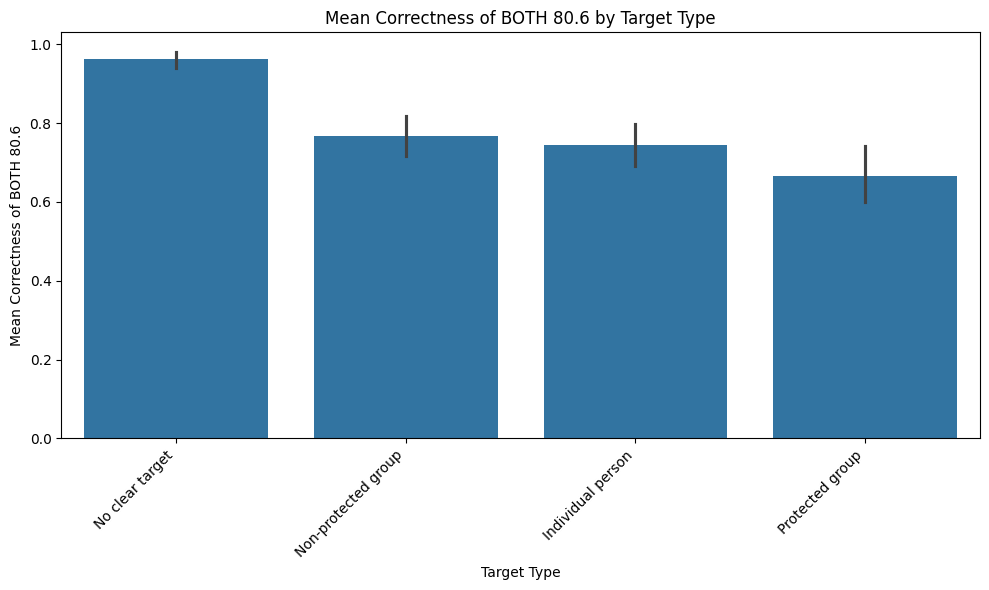

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Perform one-way ANOVA for 'Target Type' on 'both_correct'
model_both_correct_target_type = smf.ols('both_correct ~ C(Q("Target Type"))', data=df).fit()
anova_table_both_correct_target_type = sm.stats.anova_lm(model_both_correct_target_type, typ=2)
print("ANOVA for 'BOTH 80.6' Correctness by Target Type:")
print(anova_table_both_correct_target_type)

# Create bar plot for 'Target Type' on 'both_correct'
plt.figure(figsize=(10, 6))
sns.barplot(x='Target Type', y='both_correct', data=df, errorbar='ci')
plt.xlabel('Target Type')
plt.ylabel('Mean Correctness of BOTH 80.6')
plt.title('Mean Correctness of BOTH 80.6 by Target Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ANOVA for 'BOTH 80.6' Correctness by Intent Clarity:
                            sum_sq     df          F        PR(>F)
C(Q("Intent Clarity"))   12.530584    3.0  28.966367  5.826448e-18
Residual                143.908538  998.0        NaN           NaN


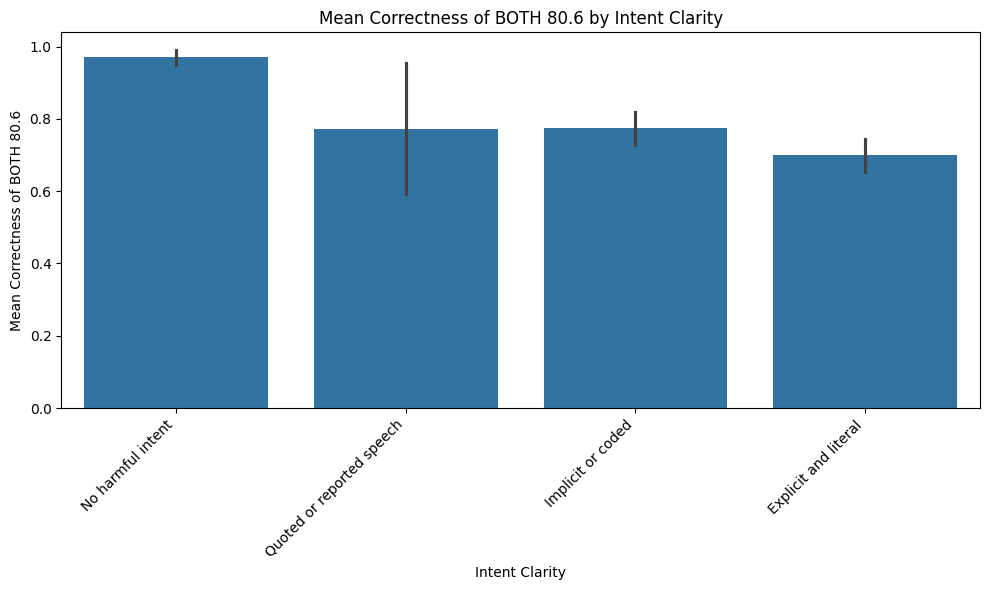

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Perform one-way ANOVA for 'Intent Clarity' on 'both_correct'
model_both_correct_intent_clarity = smf.ols('both_correct ~ C(Q("Intent Clarity"))', data=df).fit()
anova_table_both_correct_intent_clarity = sm.stats.anova_lm(model_both_correct_intent_clarity, typ=2)
print("ANOVA for 'BOTH 80.6' Correctness by Intent Clarity:")
print(anova_table_both_correct_intent_clarity)

# Create bar plot for 'Intent Clarity' on 'both_correct'
plt.figure(figsize=(10, 6))
sns.barplot(x='Intent Clarity', y='both_correct', data=df, errorbar='ci')
plt.xlabel('Intent Clarity')
plt.ylabel('Mean Correctness of BOTH 80.6')
plt.title('Mean Correctness of BOTH 80.6 by Intent Clarity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ANOVA for 'BOTH 80.6' Correctness by Context Dependence:
                                sum_sq     df         F  PR(>F)
C(Q("Context Dependence"))    0.392097    2.0  1.255087  0.2855
Residual                    156.047024  999.0       NaN     NaN


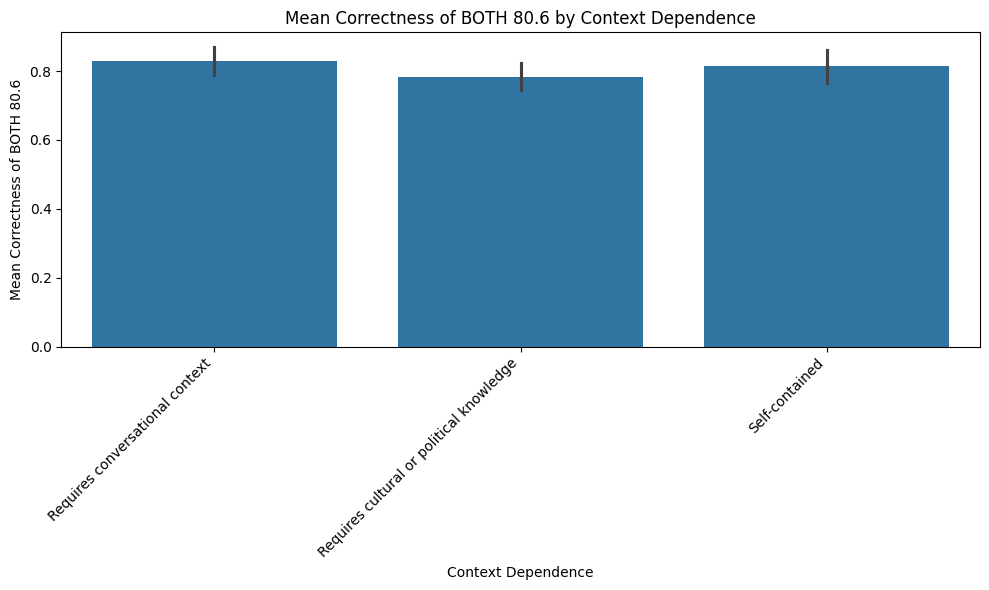

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Perform one-way ANOVA for 'Context Dependence' on 'both_correct'
model_both_correct_context_dependence = smf.ols('both_correct ~ C(Q("Context Dependence"))', data=df).fit()
anova_table_both_correct_context_dependence = sm.stats.anova_lm(model_both_correct_context_dependence, typ=2)
print("ANOVA for 'BOTH 80.6' Correctness by Context Dependence:")
print(anova_table_both_correct_context_dependence)

# Create bar plot for 'Context Dependence' on 'both_correct'
plt.figure(figsize=(10, 6))
sns.barplot(x='Context Dependence', y='both_correct', data=df, errorbar='ci')
plt.xlabel('Context Dependence')
plt.ylabel('Mean Correctness of BOTH 80.6')
plt.title('Mean Correctness of BOTH 80.6 by Context Dependence')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ANOVA for 'BERT 80.2' Correctness by Target Type:
                         sum_sq     df         F        PR(>F)
C(Q("Target Type"))   12.398378    3.0  28.04281  2.057038e-17
Residual             147.079666  998.0       NaN           NaN


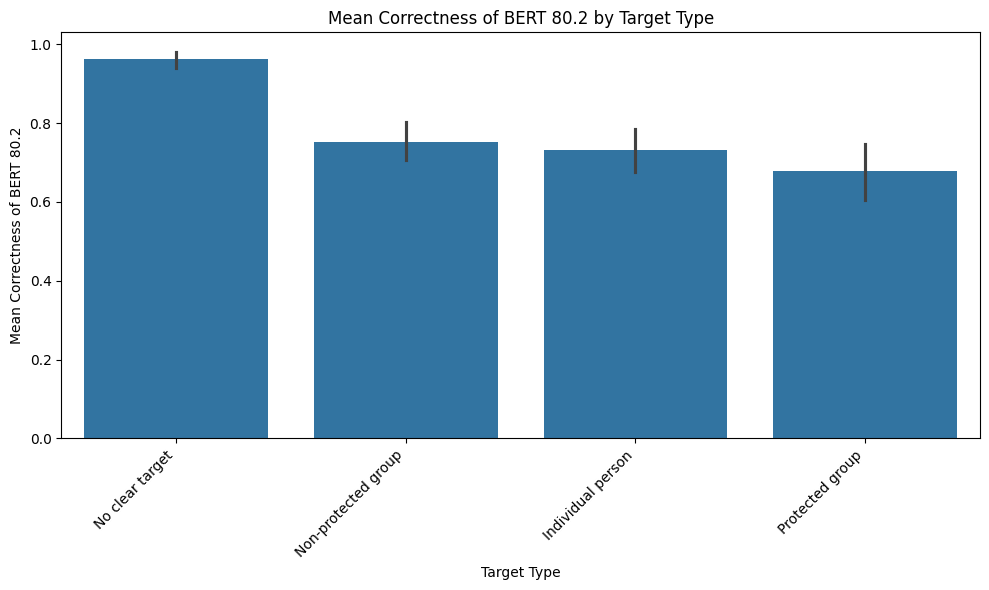

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Perform one-way ANOVA for 'Target Type' on 'bert_correct'
model_bert_correct_target_type = smf.ols('bert_correct ~ C(Q("Target Type"))', data=df).fit()
anova_table_bert_correct_target_type = sm.stats.anova_lm(model_bert_correct_target_type, typ=2)
print("ANOVA for 'BERT 80.2' Correctness by Target Type:")
print(anova_table_bert_correct_target_type)

# Create bar plot for 'Target Type' on 'bert_correct'
plt.figure(figsize=(10, 6))
sns.barplot(x='Target Type', y='bert_correct', data=df, errorbar='ci')
plt.xlabel('Target Type')
plt.ylabel('Mean Correctness of BERT 80.2')
plt.title('Mean Correctness of BERT 80.2 by Target Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ANOVA for 'BERT 80.2' Correctness by Intent Clarity:
                            sum_sq     df          F        PR(>F)
C(Q("Intent Clarity"))   12.376021    3.0  27.987987  2.217174e-17
Residual                147.102023  998.0        NaN           NaN


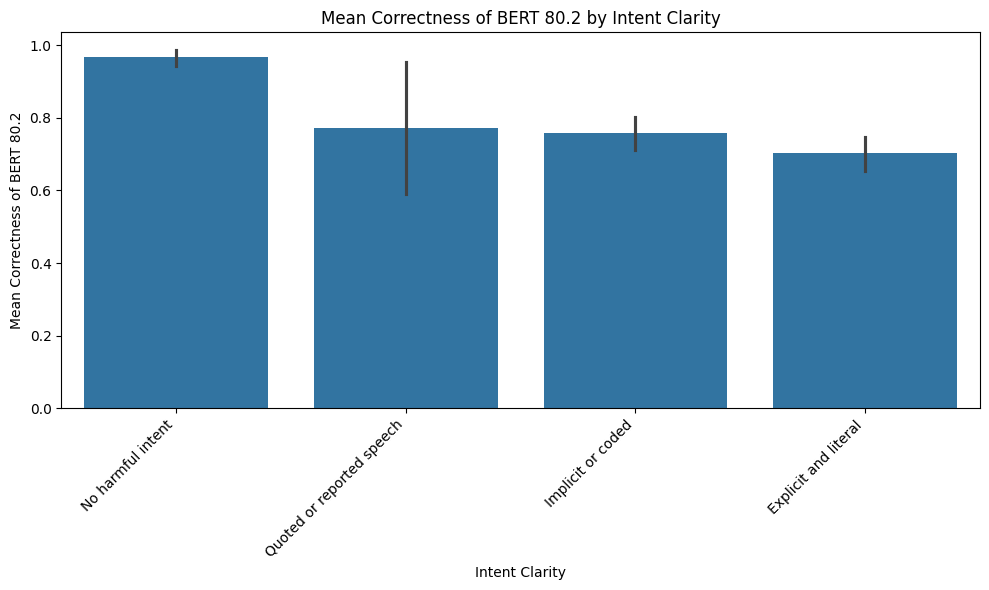

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Perform one-way ANOVA for 'Intent Clarity' on 'bert_correct'
model_bert_correct_intent_clarity = smf.ols('bert_correct ~ C(Q("Intent Clarity"))', data=df).fit()
anova_table_bert_correct_intent_clarity = sm.stats.anova_lm(model_bert_correct_intent_clarity, typ=2)
print("ANOVA for 'BERT 80.2' Correctness by Intent Clarity:")
print(anova_table_bert_correct_intent_clarity)

# Create bar plot for 'Intent Clarity' on 'bert_correct'
plt.figure(figsize=(10, 6))
sns.barplot(x='Intent Clarity', y='bert_correct', data=df, errorbar='ci')
plt.xlabel('Intent Clarity')
plt.ylabel('Mean Correctness of BERT 80.2')
plt.title('Mean Correctness of BERT 80.2 by Intent Clarity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ANOVA for 'BERT 80.2' Correctness by Context Dependence:
                                sum_sq     df        F    PR(>F)
C(Q("Context Dependence"))    0.505612    2.0  1.58866  0.204715
Residual                    158.972432  999.0      NaN       NaN


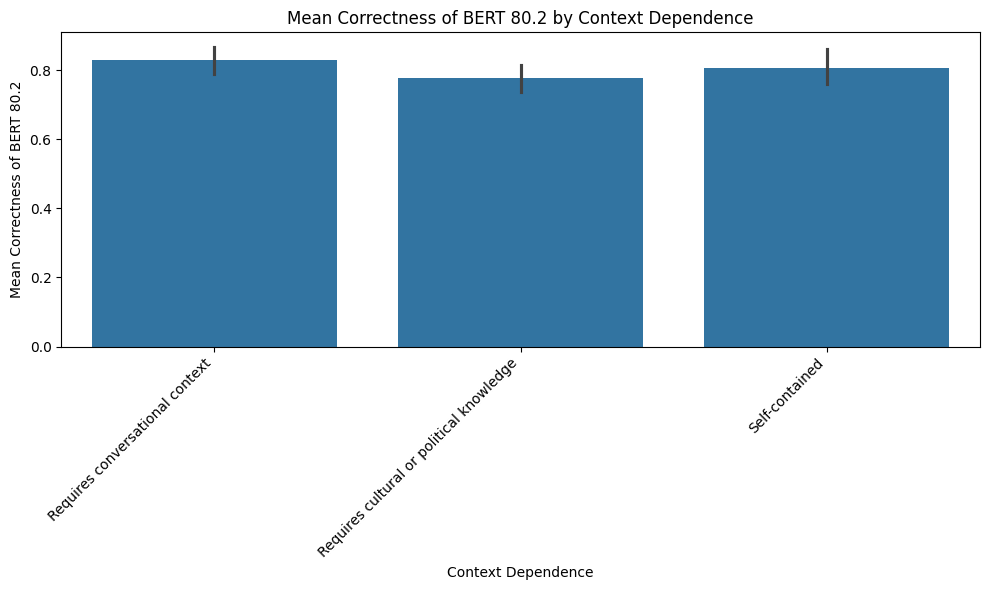

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Perform one-way ANOVA for 'Context Dependence' on 'bert_correct'
model_bert_correct_context_dependence = smf.ols('bert_correct ~ C(Q("Context Dependence"))', data=df).fit()
anova_table_bert_correct_context_dependence = sm.stats.anova_lm(model_bert_correct_context_dependence, typ=2)
print("ANOVA for 'BERT 80.2' Correctness by Context Dependence:")
print(anova_table_bert_correct_context_dependence)

# Create bar plot for 'Context Dependence' on 'bert_correct'
plt.figure(figsize=(10, 6))
sns.barplot(x='Context Dependence', y='bert_correct', data=df, errorbar='ci')
plt.xlabel('Context Dependence')
plt.ylabel('Mean Correctness of BERT 80.2')
plt.title('Mean Correctness of BERT 80.2 by Context Dependence')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Melt the DataFrame to a long format
df_long = pd.melt(df,
                  id_vars=['Target Type', 'Intent Clarity', 'Context Dependence'],
                  value_vars=['both_correct', 'bert_correct'],
                  var_name='system',
                  value_name='correctness')

# Convert 'system' column to 'category' data type
df_long['system'] = df_long['system'].astype('category')

# Convert 'correctness' column to 'int' data type (already int, but good for explicit typing)
df_long['correctness'] = df_long['correctness'].astype(int)

print("DataFrame successfully melted and columns converted.")
print(df_long.head())

DataFrame successfully melted and columns converted.
           Target Type        Intent Clarity  \
0  Non-protected group     No harmful intent   
1      Protected group  Explicit and literal   
2  Non-protected group     Implicit or coded   
3    Individual person     Implicit or coded   
4    Individual person  Explicit and literal   

                         Context Dependence        system  correctness  
0  Requires cultural or political knowledge  both_correct            1  
1  Requires cultural or political knowledge  both_correct            1  
2                            Self-contained  both_correct            1  
3           Requires conversational context  both_correct            0  
4  Requires cultural or political knowledge  both_correct            1  


Two-Way ANOVA for System and Target Type (with interaction):
                                   sum_sq      df          F        PR(>F)
C(system)                        0.012475     1.0   0.085466  7.700522e-01
C(Q("Target Type"))             24.525321     3.0  56.007528  9.305652e-35
C(system):C(Q("Target Type"))    0.046837     3.0   0.106960  9.560442e-01
Residual                       291.345008  1996.0        NaN           NaN


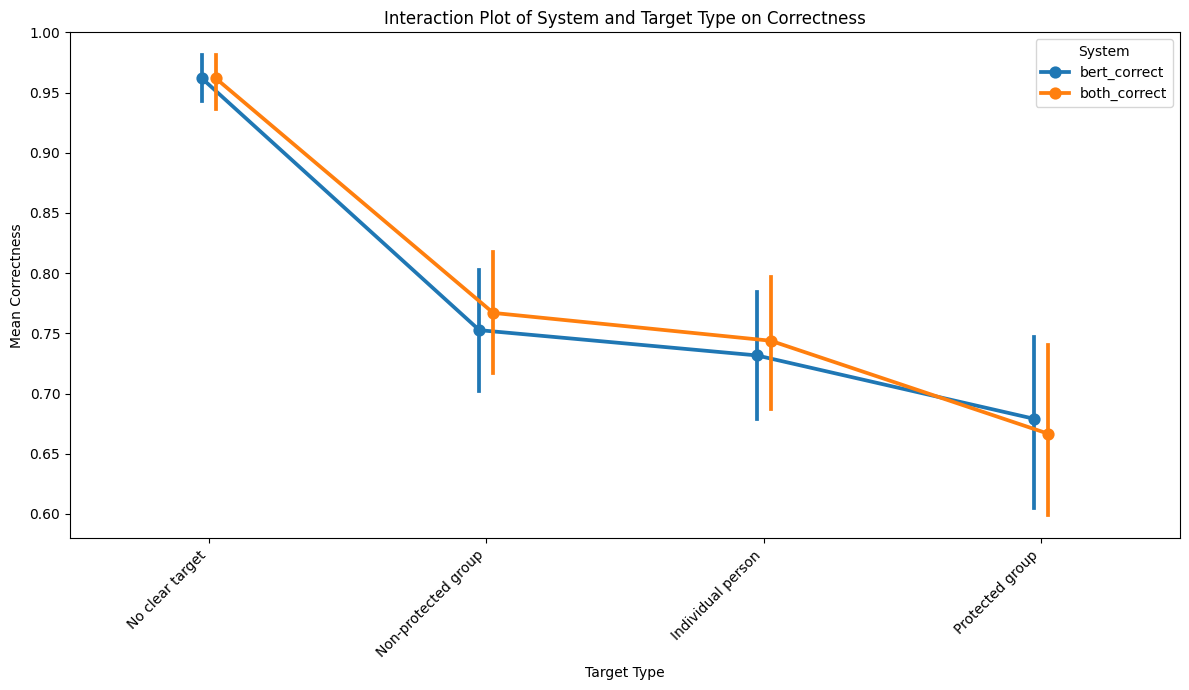

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Perform two-way ANOVA for 'system' and 'Target Type' with interaction
model_interaction_system_target_type = smf.ols('correctness ~ C(system) * C(Q("Target Type"))', data=df_long).fit()
anova_table_system_target_type = sm.stats.anova_lm(model_interaction_system_target_type, typ=2)
print("Two-Way ANOVA for System and Target Type (with interaction):")
print(anova_table_system_target_type)

# Create interaction plot
plt.figure(figsize=(12, 7))
sns.pointplot(x='Target Type', y='correctness', hue='system', data=df_long, errorbar='ci', dodge=True)
plt.xlabel('Target Type')
plt.ylabel('Mean Correctness')
plt.title('Interaction Plot of System and Target Type on Correctness')
plt.xticks(rotation=45, ha='right')
plt.legend(title='System')
plt.tight_layout()
plt.show()

Two-Way ANOVA for System and Intent Clarity (with interaction):
                                      sum_sq      df          F        PR(>F)
C(system)                           0.012475     1.0   0.085565  7.699239e-01
C(Q("Intent Clarity"))             24.875743     3.0  56.873059  2.831557e-35
C(system):C(Q("Intent Clarity"))    0.030862     3.0   0.070559  9.756757e-01
Residual                          291.010561  1996.0        NaN           NaN


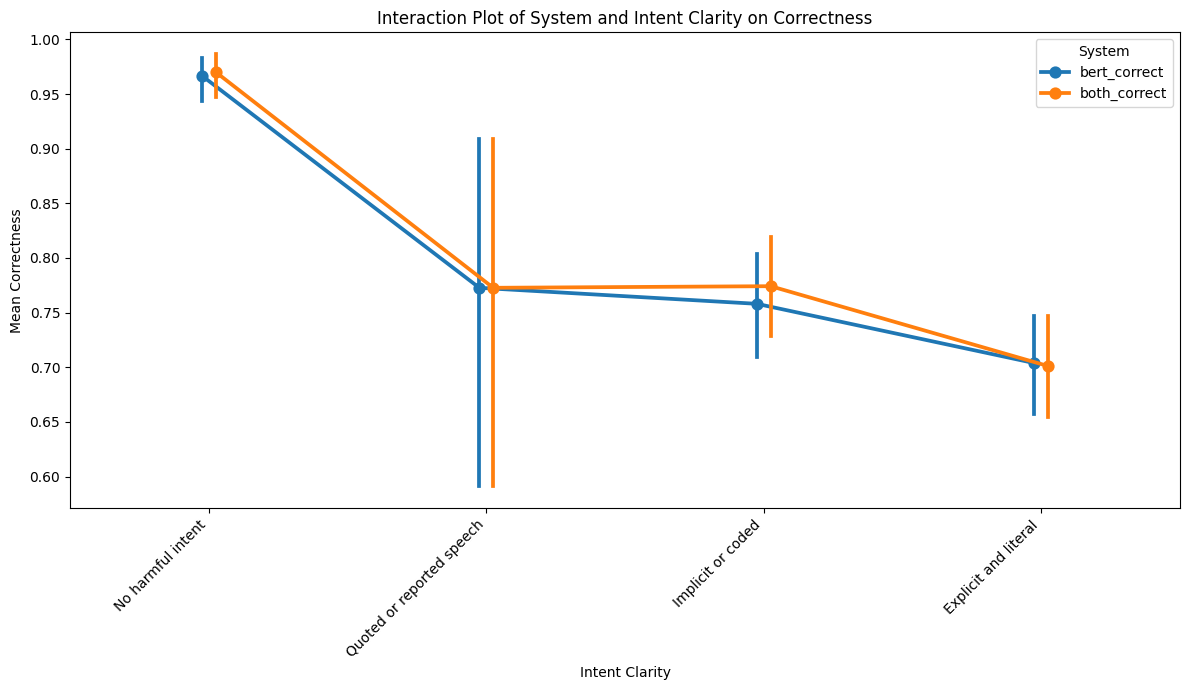

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Perform two-way ANOVA for 'system' and 'Intent Clarity' with interaction
model_interaction_system_intent_clarity = smf.ols('correctness ~ C(system) * C(Q("Intent Clarity"))', data=df_long).fit()
anova_table_system_intent_clarity = sm.stats.anova_lm(model_interaction_system_intent_clarity, typ=2)
print("Two-Way ANOVA for System and Intent Clarity (with interaction):")
print(anova_table_system_intent_clarity)

# Create interaction plot
plt.figure(figsize=(12, 7))
sns.pointplot(x='Intent Clarity', y='correctness', hue='system', data=df_long, errorbar='ci', dodge=True)
plt.xlabel('Intent Clarity')
plt.ylabel('Mean Correctness')
plt.title('Interaction Plot of System and Intent Clarity on Correctness')
plt.xticks(rotation=45, ha='right')
plt.legend(title='System')
plt.tight_layout()
plt.show()

Two-Way ANOVA for System and Context Dependence (with interaction):
                                          sum_sq      df         F    PR(>F)
C(system)                               0.012475     1.0  0.079123  0.778519
C(Q("Context Dependence"))              0.891092     2.0  2.825860  0.059495
C(system):C(Q("Context Dependence"))    0.006617     2.0  0.020985  0.979234
Residual                              315.019457  1998.0       NaN       NaN


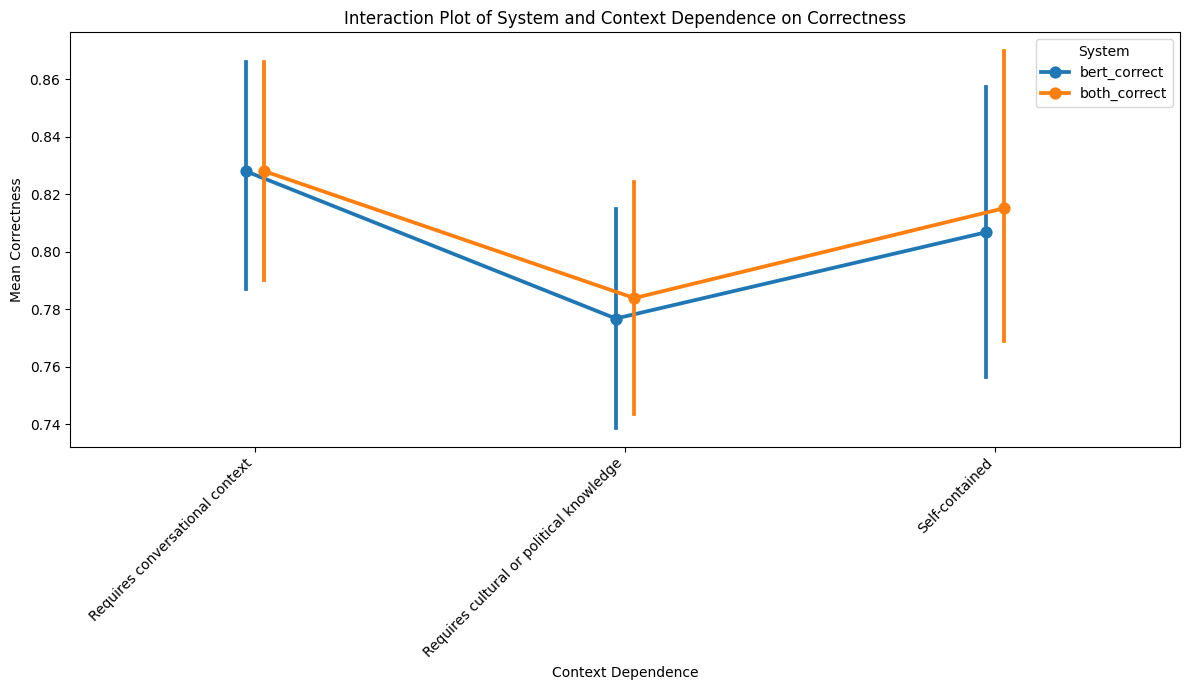

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Perform two-way ANOVA for 'system' and 'Context Dependence' with interaction
model_interaction_system_context_dependence = smf.ols('correctness ~ C(system) * C(Q("Context Dependence"))', data=df_long).fit()
anova_table_system_context_dependence = sm.stats.anova_lm(model_interaction_system_context_dependence, typ=2)
print("Two-Way ANOVA for System and Context Dependence (with interaction):")
print(anova_table_system_context_dependence)

# Create interaction plot
plt.figure(figsize=(12, 7))
sns.pointplot(x='Context Dependence', y='correctness', hue='system', data=df_long, errorbar='ci', dodge=True)
plt.xlabel('Context Dependence')
plt.ylabel('Mean Correctness')
plt.title('Interaction Plot of System and Context Dependence on Correctness')
plt.xticks(rotation=45, ha='right')
plt.legend(title='System')
plt.tight_layout()
plt.show()